In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
img_path = Path("../../images/man.jpg")

In [10]:
IS_DRAWING = False
BRUSH_SIZE = 5

def draw_mask(img, window_name, mask):
    draw_img = img.copy()
    def callback(event,x,y,flags,param):
        global IS_DRAWING
        if event == cv.EVENT_LBUTTONDOWN:
            IS_DRAWING = True
        if event == cv.EVENT_LBUTTONUP:
            IS_DRAWING = False
        if IS_DRAWING and event == cv.EVENT_MOUSEMOVE:
            cv.circle(draw_img,(x,y),BRUSH_SIZE,(255,255,255),-1)
            cv.circle(mask,(x,y),BRUSH_SIZE,(255,255,255),-1)
            cv.imshow(window_name, draw_img)

    return callback


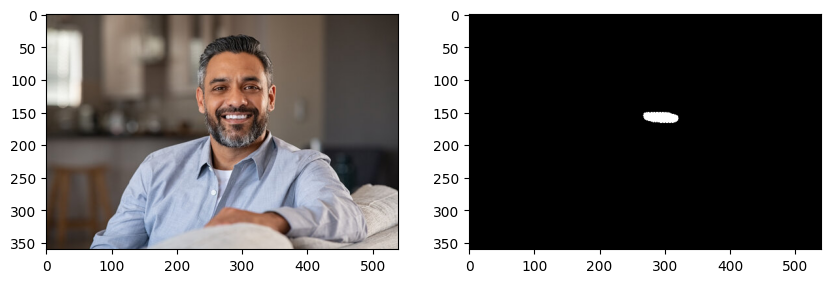

In [11]:
WINDOW_NAME = "Draw Mask"
cv.namedWindow(WINDOW_NAME)
img = cv.imread(img_path)
mask = np.zeros(img.shape[:2], np.uint8)

cv.setMouseCallback(WINDOW_NAME, draw_mask(img, WINDOW_NAME, mask))
cv.imshow(WINDOW_NAME, img)
cv.waitKey(0)
cv.destroyAllWindows()

plt.figure(figsize=(10,10))
plt.subplot(121); plt.imshow(img[...,::-1])
plt.subplot(122); plt.imshow(mask, cmap='gray')

In [20]:
cv.imwrite(img_path.parent / f"{img_path.stem}_mask.png", mask)

True